<a href="https://colab.research.google.com/github/kalyani-n2711/PCOS-Ultrasound-Analysis/blob/main/IBD%26CT_ULTRASOUND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
zip_path = '/content/drive/MyDrive/archive2.zip'
extract_to = '/content/drive/MyDrive/extracted_files_2'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)
print("Files extracted to", extract_to)



Files extracted to /content/drive/MyDrive/extracted_files_2


In [ ]:
from google.colab import drive
import zipfile
import os
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/archive2.zip'
extract_to = '/content/drive/MyDrive/extracted_files_2'
extracted_folder_pcos = '/content/drive/MyDrive/extracted_files_2/dataset/pcos'
extracted_folder_normal = '/content/drive/MyDrive/extracted_files_2/dataset/normal'
def count_images(folder_path):
    return sum(1 for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')))
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Files extracted to", extract_to)
    pcos_image_count = count_images(extracted_folder_pcos)
    normal_image_count = count_images(extracted_folder_normal)
    print("Total Images in PCOS folder:", pcos_image_count)
    print("Total Images in Normal folder:", normal_image_count)
    print("Total Images in the dataset:", pcos_image_count + normal_image_count)
else:
    print("Error: Zip file not found at", zip_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files extracted to /content/drive/MyDrive/extracted_files_2
Total Images in PCOS folder: 500
Total Images in Normal folder: 500
Total Images in the dataset: 1000


In [ ]:
#2.Image Preprocessing and Augmentation
import cv2
import os
import matplotlib.pyplot as plt

class OvarianImagePreprocessor:
    def __init__(self, image_path):
        self.image = cv2.imread(image_path)

    def crop_image(self, x, y, w, h):
        return self.image[y:y+h, x:x+w]

    def augment_image(self, cropped_image):
        return {'horizontal_flip': cv2.flip(cropped_image, 1),
            'vertical_flip': cv2.flip(cropped_image, 0),
            'rotation_90': cv2.rotate(cropped_image, cv2.ROTATE_90_CLOCKWISE),
            'scaling_150': cv2.resize(cropped_image, None, fx=1.5, fy=1.5)}
    def edge_detection(self, cropped_image):
        return cv2.Canny(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY), 100, 200)

    def draw_contours(self, cropped_image, edges):
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        return cv2.drawContours(cropped_image.copy(), contours, -1, (0, 255, 0), 2)

    def visualize(self, cropped_image, augmented_images, edges, contour_image):
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        images = [
            (cropped_image, "Cropped Image"), (augmented_images['horizontal_flip'], "Horizontal Flip"),
            (augmented_images['vertical_flip'], "Vertical Flip"), (augmented_images['rotation_90'], "Rotation 90°"),
            (augmented_images['scaling_150'], "Scaled (150%)"), (contour_image, "Contours")]
        for ax, (img, title) in zip(axes.ravel(), images):
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape) == 3 else img)
            ax.set_title(title)
            ax.axis('off')
        plt.tight_layout()
        plt.show()
def process_images_in_directory(directory_path):
    for filename in os.listdir(directory_path):
        if filename.endswith((".jpg", ".png")):
            image_path = os.path.join(directory_path, filename)
            preprocessor = OvarianImagePreprocessor(image_path)
            cropped_image = preprocessor.crop_image(100, 100, 300, 300)
            augmented_images = preprocessor.augment_image(cropped_image)
            edges = preprocessor.edge_detection(cropped_image)
            contour_image = preprocessor.draw_contours(cropped_image, edges)
            preprocessor.visualize(cropped_image, augmented_images, edges, contour_image)
def process_dataset(Dataset_Dir):
    for class_folder in ['pcos', 'normal']:
        class_path = os.path.join(Dataset_Dir, class_folder)
        if os.path.isdir(class_path):
            process_images_in_directory(class_path)
def main():
    dataset_directory = '/content/drive/MyDrive/extracted_files_2/dataset/'
    process_dataset(dataset_directory)
if __name__ == "__main__":
    main()


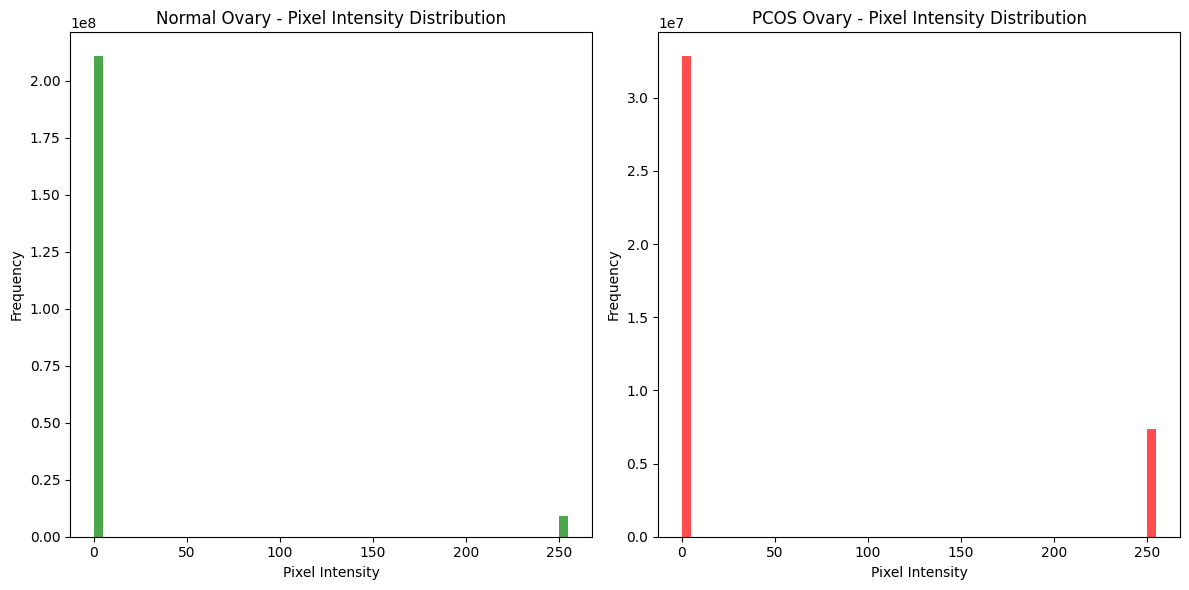

In [ ]:
#3.Compare Pixel Intensity (Normal vs. PCOS)
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

class ImageProcessor:
    def __init__(self, normal_directory, pcos_directory):
        self.normal_directory = normal_directory
        self.pcos_directory = pcos_directory
        self.normal_images = [f for f in os.listdir(self.normal_directory) if f.endswith(('.jpg', '.png'))]
        self.pcos_images = [f for f in os.listdir(self.pcos_directory) if f.endswith(('.jpg', '.png'))]

    def process_image(self, image_path):
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Failed to load image: {image_path}")
        binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)[1]
        return binary.flatten()

    def compare_pixel_intensity(self):
        normal_data_flat = np.concatenate([self.process_image(os.path.join(self.normal_directory, f)) for f in self.normal_images])
        pcos_data_flat = np.concatenate([self.process_image(os.path.join(self.pcos_directory, f)) for f in self.pcos_images])

        # Plot histograms
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        axes[0].hist(normal_data_flat, bins=50, color='green', alpha=0.7)
        axes[0].set_title("Normal Ovary - Pixel Intensity Distribution")
        axes[0].set_xlabel("Pixel Intensity")
        axes[0].set_ylabel("Frequency")

        axes[1].hist(pcos_data_flat, bins=50, color='red', alpha=0.7)
        axes[1].set_title("PCOS Ovary - Pixel Intensity Distribution")
        axes[1].set_xlabel("Pixel Intensity")
        axes[1].set_ylabel("Frequency")
        plt.tight_layout()
        plt.show()
normal_directory = '/content/drive/MyDrive/extracted_files_2/dataset/normal'
pcos_directory = '/content/drive/MyDrive/extracted_files_2/dataset/pcos'
processor = ImageProcessor(normal_directory, pcos_directory)
processor.compare_pixel_intensity()


In [ ]:
#4.Image Comparison of Normal and PCOS Ovaries
import cv2
import matplotlib.pyplot as plt
import os

def process_images(normal_directory, pcos_directory):
    normal_images = sorted(os.listdir(normal_directory))
    pcos_images = sorted(os.listdir(pcos_directory))

    for normal_img, pcos_img in zip(normal_images, pcos_images):
        normal_path = os.path.join(normal_directory, normal_img)
        pcos_path = os.path.join(pcos_directory, pcos_img)

        normal = cv2.imread(normal_path)
        pcos = cv2.imread(pcos_path)

        normal_gray = cv2.cvtColor(normal, cv2.COLOR_BGR2GRAY)
        pcos_gray = cv2.cvtColor(pcos, cv2.COLOR_BGR2GRAY)

        _, normal_bin = cv2.threshold(normal_gray, 127, 255, cv2.THRESH_BINARY)
        _, pcos_bin = cv2.threshold(pcos_gray, 127, 255, cv2.THRESH_BINARY)

        fig, axes = plt.subplots(3, 2, figsize=(12, 10))

        axes[0, 0].imshow(cv2.cvtColor(normal, cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title(f'{normal_img} (RGB)')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(cv2.cvtColor(pcos, cv2.COLOR_BGR2RGB))
        axes[0, 1].set_title(f'{pcos_img} (RGB)')
        axes[0, 1].axis('off')

        axes[1, 0].imshow(normal_gray, cmap='gray')
        axes[1, 0].set_title(f'{normal_img} (Grayscale)')
        axes[1, 0].axis('off')

        axes[1, 1].imshow(pcos_gray, cmap='gray')
        axes[1, 1].set_title(f'{pcos_img} (Grayscale)')
        axes[1, 1].axis('off')

        axes[2, 0].imshow(normal_bin, cmap='gray')
        axes[2, 0].set_title(f'{normal_img} (Binary)')
        axes[2, 0].axis('off')

        axes[2, 1].imshow(pcos_bin, cmap='gray')
        axes[2, 1].set_title(f'{pcos_img} (Binary)')
        axes[2, 1].axis('off')

        plt.subplots_adjust(wspace=0.3, hspace=0.5)
        plt.tight_layout()
        plt.show()

def main():
    normal_directory = '/content/drive/MyDrive/extracted_files_2/dataset/normal'
    pcos_directory = '/content/drive/MyDrive/extracted_files_2/dataset/normal'
    process_images(normal_directory, pcos_directory)

if __name__ == "__main__":
    main()


In [ ]:
#5.Heatmap Comparison (Normal vs. PCOS)
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

class PCOSComparison:
    def __init__(self, normal_directory, pcos_directory):
        self.normal_directory = normal_directory
        self.pcos_directory = pcos_directory
        self.target_size = (256, 256)

    def process_images_in_directory(self):
        normal_images = sorted(os.listdir(self.normal_directory))
        pcos_images = sorted(os.listdir(self.pcos_directory))
        if len(normal_images) != len(pcos_images):
            print("Warning: Mismatch in number of images between normal and PCOS directories.")
        for normal_file, pcos_file in zip(normal_images, pcos_images):
            normal_path = os.path.join(self.normal_directory, normal_file)
            pcos_path = os.path.join(self.pcos_directory, pcos_file)
            print("Processing:", normal_file, "vs.", pcos_file)
            self.compare_images(normal_path, pcos_path)

    def compare_images(self, normal_path, pcos_path):
        normal_image = cv2.imread(normal_path, cv2.IMREAD_GRAYSCALE)
        pcos_image = cv2.imread(pcos_path, cv2.IMREAD_GRAYSCALE)

        if normal_image is None or pcos_image is None:
            print("Error loading images:", normal_path, "or", pcos_path)
            return

        normal_image = cv2.resize(normal_image, self.target_size, interpolation=cv2.INTER_AREA)
        pcos_image = cv2.resize(pcos_image, self.target_size, interpolation=cv2.INTER_AREA)
        self.plot_heatmaps(normal_image, pcos_image, normal_path, pcos_path)

    def plot_heatmaps(self, normal_image, pcos_image, normal_path, pcos_path):
        plt.figure(figsize=(15, 7))
        plt.subplot(1, 3, 1)
        sns.heatmap(normal_image, cmap="Blues", cbar=True)
        plt.title("Normal Ovary: " + os.path.basename(normal_path))

        plt.subplot(1, 3, 2)
        sns.heatmap(pcos_image, cmap="Reds", cbar=True)
        plt.title("PCOS Ovary: " + os.path.basename(pcos_path))

        difference = np.abs(normal_image - pcos_image)
        plt.subplot(1, 3, 3)
        sns.heatmap(difference, cmap="coolwarm", cbar=True)
        plt.title("Difference Overlay Heatmap")

        plt.tight_layout()
        plt.show()

normal_directory = '/content/drive/MyDrive/extracted_files_2/dataset/normal'
pcos_directory = '/content/drive/MyDrive/extracted_files_2/dataset/pcos'
comparison = PCOSComparison(normal_directory, pcos_directory)
comparison.process_images_in_directory()


In [ ]:
#6. Follicle Overlay and Highlighting
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

class OvaryAnalysis:
    def __init__(self, normal_directory, pcos_directory):
        self.normal_directory = normal_directory
        self.pcos_directory = pcos_directory
        self.normal_images = sorted(os.listdir(normal_directory))
        self.pcos_images = sorted(os.listdir(pcos_directory))

    def load_images(self, normal_image_path, pcos_image_path):
        self.normal_image = cv2.imread(normal_image_path, cv2.IMREAD_GRAYSCALE)
        self.pcos_image = cv2.imread(pcos_image_path, cv2.IMREAD_GRAYSCALE)

    def process_image(self, image):
        _, thresh = cv2.threshold(image, 120, 255, cv2.THRESH_BINARY_INV)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        return contours, thresh

    def analyze_images(self):
        normal_contours, _ = self.process_image(self.normal_image)
        pcos_contours, _ = self.process_image(self.pcos_image)

        self.normal_overlay = cv2.cvtColor(self.normal_image, cv2.COLOR_GRAY2RGB)
        self.pcos_overlay = cv2.cvtColor(self.pcos_image, cv2.COLOR_GRAY2RGB)
        cv2.drawContours(self.normal_overlay, normal_contours, -1, (0, 255, 0), 2)
        cv2.drawContours(self.pcos_overlay, pcos_contours, -1, (255, 0, 0), 2)

    def visualize_results(self, normal_image_name, pcos_image_name):
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        axes[0].imshow(self.normal_overlay)
        axes[0].set_title(normal_image_name + ' - Normal Ovary with Follicles')
        axes[0].axis('off')

        axes[1].imshow(self.pcos_overlay)
        axes[1].set_title(pcos_image_name + ' - PCOS Ovary with Follicles')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    def process_all_images(self):
        for normal_image_name, pcos_image_name in zip(self.normal_images, self.pcos_images):
            normal_image_path = os.path.join(self.normal_directory, normal_image_name)
            pcos_image_path = os.path.join(self.pcos_directory, pcos_image_name)

            self.load_images(normal_image_path, pcos_image_path)
            self.analyze_images()
            self.visualize_results(normal_image_name, pcos_image_name)

normal_directory = '/content/drive/MyDrive/extracted_files_2/dataset/normal'
pcos_directory = '/content/drive/MyDrive/extracted_files_2/dataset/pcos'
analysis = OvaryAnalysis(normal_directory, pcos_directory)
analysis.process_all_images()


In [ ]:
#7.Convert Image to DataFrame
import cv2
import pandas as pd
import numpy as np
import os

class ImageAnalysis:
    def __init__(self, normal_directory, pcos_directory):
        self.normal_directory = normal_directory
        self.pcos_directory = pcos_directory
        self.normal_dataframes = []
        self.pcos_dataframes = []

    def convert_image_to_dataframe(self, image_path):
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image_flat = image.flatten()
        return pd.DataFrame(image_flat, columns=['Pixel Intensity'])

    def process_images(self):
        normal_images = sorted(os.listdir(self.normal_directory))
        pcos_images = sorted(os.listdir(self.pcos_directory))

        for normal_image in normal_images:
            normal_image_path = os.path.join(self.normal_directory, normal_image)
            normal_df = self.convert_image_to_dataframe(normal_image_path)
            normal_df['Class'] = 'Normal'
            self.normal_dataframes.append(normal_df)

        for pcos_image in pcos_images:
            pcos_image_path = os.path.join(self.pcos_directory, pcos_image)
            pcos_df = self.convert_image_to_dataframe(pcos_image_path)
            pcos_df['Class'] = 'PCOS'
            self.pcos_dataframes.append(pcos_df)

    def analyze_dataset(self):
        all_data = pd.concat(self.normal_dataframes + self.pcos_dataframes, ignore_index=True)
        return all_data.groupby('Class')['Pixel Intensity'].describe()

normal_directory = '/content/drive/MyDrive/extracted_files_2/dataset/normal'
pcos_directory = '/content/drive/MyDrive/extracted_files_2/dataset/pcos'
analysis = ImageAnalysis(normal_directory, pcos_directory)
analysis.process_images()
statistics = analysis.analyze_dataset()
print(statistics)


In [ ]:
#8. Visualization and Analysis
import cv2
import pandas as pd
import numpy as np
import os

class ImageAnalysis:
    def __init__(self, normal_directory, pcos_directory):
        self.normal_directory = normal_directory
        self.pcos_directory = pcos_directory
        self.normal_dataframes = []
        self.pcos_dataframes = []

    def convert_image_to_dataframe(self, image_path):
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image_flat = image.flatten()
        image_df = pd.DataFrame(image_flat, columns=['Pixel Intensity'])
        return image_df

    def process_images(self):
        normal_images = sorted(os.listdir(self.normal_directory))
        pcos_images = sorted(os.listdir(self.pcos_directory))

        for normal_image in normal_images:
            normal_image_path = os.path.join(self.normal_directory, normal_image)
            normal_df = self.convert_image_to_dataframe(normal_image_path)
            normal_df['Class'] = 'Normal'
            self.normal_dataframes.append(normal_df)

        for pcos_image in pcos_images:
            pcos_image_path = os.path.join(self.pcos_directory, pcos_image)
            pcos_df = self.convert_image_to_dataframe(pcos_image_path)
            pcos_df['Class'] = 'PCOS'
            self.pcos_dataframes.append(pcos_df)

    def analyze_dataset(self):
        all_data = pd.concat(self.normal_dataframes + self.pcos_dataframes, ignore_index=True)
        statistics = all_data.groupby('Class')['Pixel Intensity'].describe()
        print(statistics)
        return statistics

normal_directory = '/content/drive/MyDrive/extracted_files_2/dataset/normal'
pcos_directory = '/content/drive/MyDrive/extracted_files_2/dataset/pcos'
analysis = ImageAnalysis(normal_directory, pcos_directory)
analysis.process_images()
statistics = analysis.analyze_dataset()


In [ ]:
import os

def safe_image_processing(image_path):
    try:
        # Placeholder for actual image processing logic
        processed_image = image_path
        return processed_image
    except Exception as e:
        print("Error processing image:", image_path, "-", e)
        return None

def process_dataset(image_folder):
    processed_images = []
    try:
        for image_file in os.listdir(image_folder):
            try:
                image_path = os.path.join(image_folder, image_file)
                if not image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    print("Skipping unsupported file:", image_file)
                    continue
                processed_image = safe_image_processing(image_path)
                if processed_image is not None:
                    processed_images.append(processed_image)
                else:
                    print("Failed to process image:", image_file)
            except Exception as e:
                print("Error handling file:", image_file, "-", e)
    except Exception as e:
        print("Error accessing folder:", image_folder, "-", e)
    return processed_images

image_folder = '/content/drive/MyDrive/extracted_files_2'
processed_images_dataset = process_dataset(image_folder)

print("Processed", len(processed_images_dataset), "images successfully.")



Skipping unsupported file: dataset
Processed 0 images successfully.
